In [62]:
import os
import json
import numpy as np
import rescomp as rc
from rescomp import optimizer as rcopt
from scipy import sparse
import networkx as nx
from utils import get_components, get_response
from rescomp.optimizer.optimizer_functions import get_vptime
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

Load network and build reservoir computer around it

In [13]:
# Setup
system_name = "lorenz"
system = rcopt.get_system(system_name)
hyper_parameters = rc.SYSTEMS[system_name]["rcomp_params"]

In [16]:
A_loaded = sparse.load_npz("subjects/network_000.npz")
G_loaded = nx.DiGraph(A_loaded)

resA = rc.ResComp(A_loaded,**hyper_parameters)

Train reservoir with default hyperparameters and check VPT

In [17]:
# Train reservoir with default hyperparameters
tr, Utr, ts, Uts = rc.train_test_orbit(system_name, duration=1000, trainper=980/1000)
resA.train(tr, Utr)

# Evaluate VPT
pre = resA.predict(ts, r0=resA.r0)
vpt = get_vptime(system, ts, Uts, pre, vpttol=0.5)
print(f"VPT: {vpt:.3f}")

VPT: 2.690


In [18]:
responseA = get_response(resA,ts,Uts)

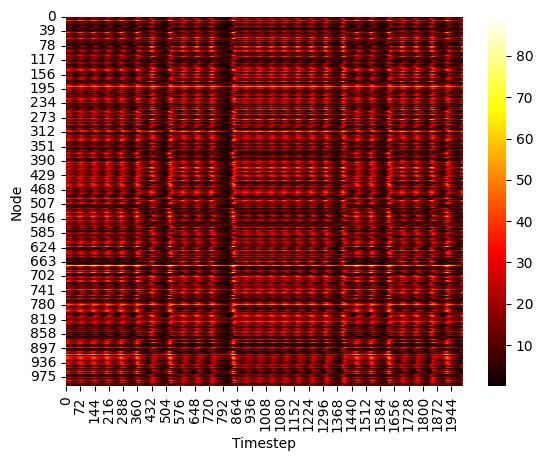

In [27]:
sns.heatmap(responseA, cmap='hot')
plt.xlabel("Timestep")
plt.ylabel("Node")
plt.savefig("network_000_heatmap.png")
plt.show()

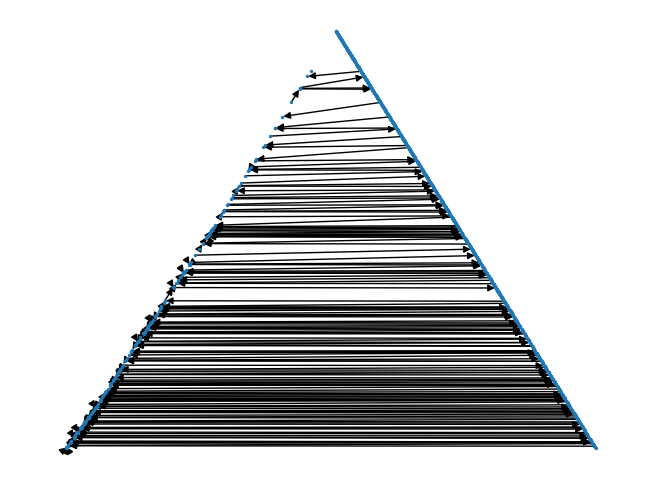

In [28]:
pos = nx.planar_layout(G_loaded)
nx.draw(G_loaded, pos, with_labels=False, node_size=2)

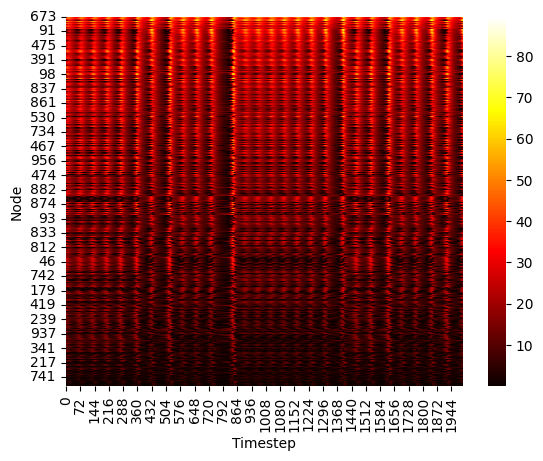

In [59]:
mean_responseA = np.asarray(responseA).mean(axis=1).squeeze() # Convert numpy matrix to ndarray
sorted_idx = np.argsort(mean_responseA)[::-1]
ax = sns.heatmap(responseA[sorted_idx], cmap='hot')
ax.set_yticks(range(0, len(sorted_idx), 39))
ax.set_yticklabels(sorted_idx[::39])
plt.xlabel("Timestep")
plt.ylabel("Node")
plt.show()

Generate a graph heatmap for timestamp `t=500`

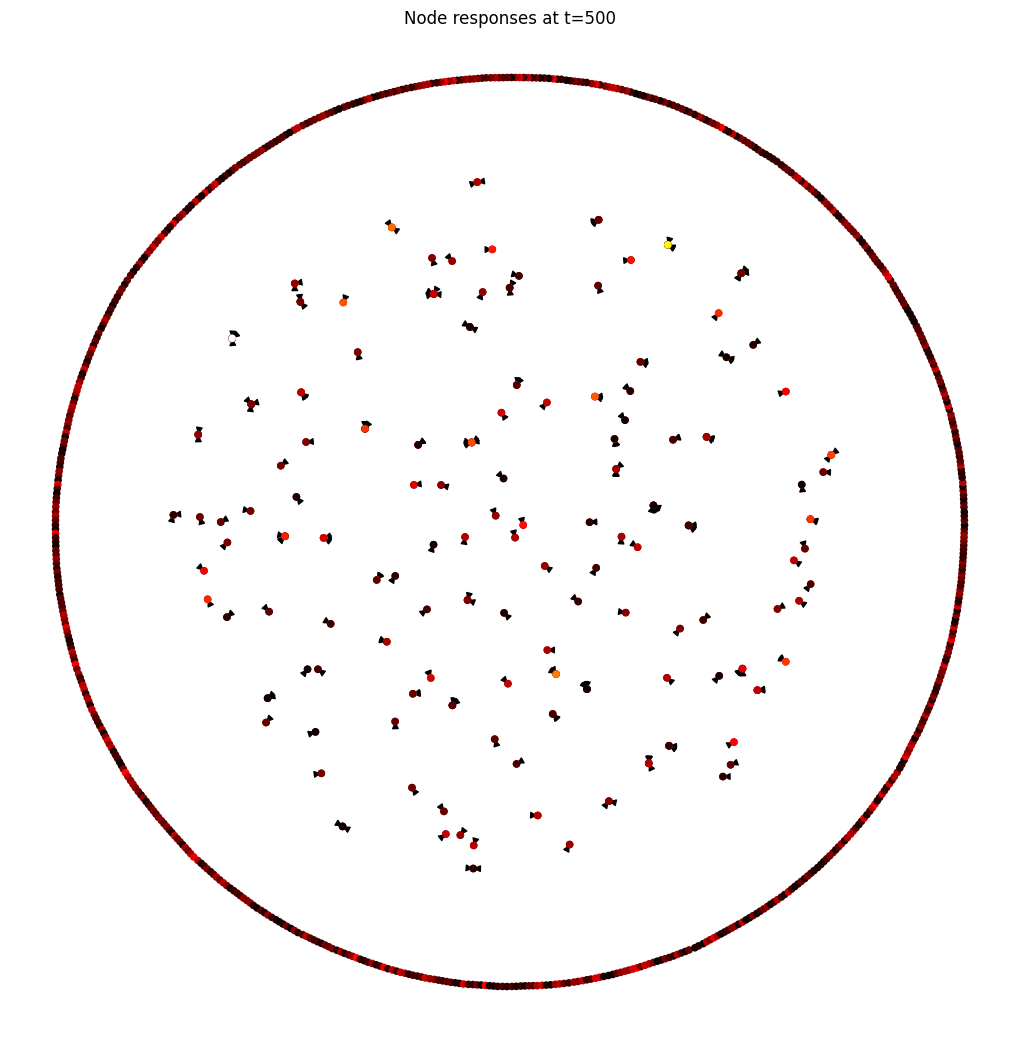

In [63]:
# Pick a timestep
t = 500

# Get response values for that timestep
node_colors_raw = np.asarray(responseA)[:, t]

# Normalize to [0, 1] for colormap
norm = mcolors.Normalize(vmin=node_colors_raw.min(), vmax=node_colors_raw.max())
node_colors = cm.hot(norm(node_colors_raw))

plt.figure(figsize=(10, 10))
nx.draw(G_loaded, pos=nx.kamada_kawai_layout(G_loaded), node_color=node_colors, node_size=20, with_labels=False)
plt.title(f"Node responses at t={t}")
plt.show()